In [1]:
import os
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr, kruskal, entropy

import dandelion as ddl

In [2]:
adata_cd4 = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad")
adata_cd4.var_names_make_unique()
adata_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

### Load vdj object

In [3]:
vdj_cd4 = ddl.read_10x_vdj("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final/cd4",filename_prefix="filtered")
vdj_cd4

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 571042 and n_contigs = 1119731
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, locus_status, chain_status, rearrangement_status_VDJ, re

### restrict adata to match vdj object

In [4]:

vdj_ids_cd4 = (
    vdj_cd4.data
    .select("cell_id")
    .unique()
    .collect()
    .to_pandas()["cell_id"]
    .astype(str)
)

rna_ids_cd4 = adata_cd4.obs_names.astype(str)

matched = len(set(vdj_ids_cd4) & set(rna_ids_cd4))
only_in_rna = len(set(rna_ids_cd4) - set(vdj_ids_cd4))
only_in_vdj = len(set(vdj_ids_cd4) - set(rna_ids_cd4))

print("Matched:", matched)
print("Only in RNA:", only_in_rna)
print("Only in VDJ:", only_in_vdj)



Matched: 571042
Only in RNA: 25444
Only in VDJ: 0


In [5]:

mask = adata_cd4.obs_names.isin(vdj_ids_cd4)

obs_cols_keep = [
    "status",
    "assignment",
    "pica_id",
    "pool_id",
    "sequencing_batch",
    "Sex",
    "Age_years",
    "Batch",
    "Age_group",
    "cell_type",
    "pica_cell_type_complete_01_gdT_corrected",
    "leiden"
]

obs_cols_keep = [c for c in obs_cols_keep if c in adata_cd4.obs.columns]

adata_cd4_sub = ad.AnnData(
    obs=adata_cd4.obs.loc[mask, obs_cols_keep].copy()
)
adata_cd4_sub.obs_names = adata_cd4.obs_names[mask].copy()

if "X_umap" in adata_cd4.obsm:
    adata_cd4_sub.obsm["X_umap"] = adata_cd4.obsm["X_umap"][mask].copy()

if "X_scVI" in adata_cd4.obsm:
    adata_cd4_sub.obsm["X_scVI"] = adata_cd4.obsm["X_scVI"][mask].copy()

print(adata_cd4_sub)

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden'
    obsm: 'X_umap', 'X_scVI'


In [6]:
# QC: Remove low quality contigs 
vdj_cd4, adata_cd4_sub = ddl.pp.check_contigs(
    vdj_cd4,
    adata=adata_cd4_sub,
    library_type="tr-ab"
)

print(vdj_cd4)
print(adata_cd4_sub)


Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 571042 and n_contigs = 1250829
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_c

In [7]:
# Compute clone sizes
ddl.tl.clone_size(vdj_cd4)
vdj_cd4

Lazy Dandelion object with n_obs = 571042 and n_contigs = 1250829
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_c

### Transfer VDJ information into Scanpy object

In [8]:
ddl.tl.transfer(adata_cd4_sub, vdj_cd4)
print([c for c in adata_cd4_sub.obs.columns if "clone" in c.lower() or "contig" in c.lower()])

['has_contig', 'clone_id', 'clone_id_rank', 'clone_id_size', 'clone_id_size_prop', 'clone_id_size_category']


In [9]:
print(adata_cd4_sub.obs["clone_id_size_category"].astype(str).value_counts(dropna=False))
print(adata_cd4_sub.obs["clone_id_size"].value_counts(dropna=False).head(20))

clone_id_size_category
Rare     569266
Small      1776
Name: count, dtype: int64
clone_id_size
21    58758
22    57266
20    56720
19    50293
23    48047
18    42228
24    36360
17    30974
25    26950
16    25088
15    18600
26    18018
14    13594
13    11557
27    10368
12     8640
11     7337
10     6560
28     5964
9      5328
Name: count, dtype: int64


In [10]:
pd.crosstab(
    adata_cd4_sub.obs["clone_id_size_category"],
    adata_cd4_sub.obs["clone_id_size"]
)

clone_id_size,1,2,3,4,5,6,7,8,9,10,...,75,84,87,96,98,106,147,157,283,317
clone_id_size_category,,,,,,,,,,,,,,,,,,,,,
Rare,2575,1566,1380,1576,2125,2772,3766,5056,5328,6560,...,0,0,0,0,0,0,0,0,0,0
Small,0,0,0,0,0,0,0,0,0,0,...,75,84,87,96,98,106,147,157,283,317


<Axes: xlabel='clone_id_size', ylabel='Count'>

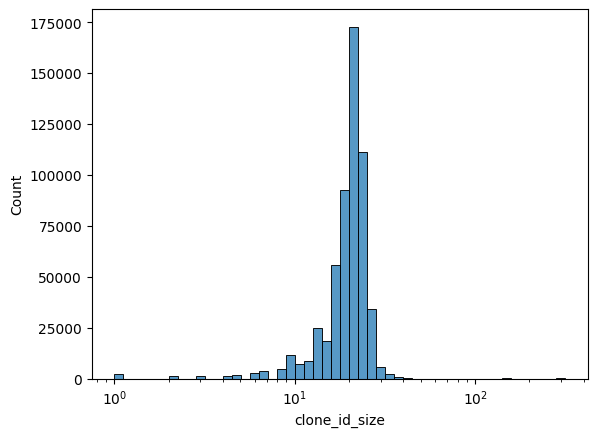

In [11]:
sns.histplot(
    adata_cd4_sub.obs["clone_id_size"],
    bins=50,
    log_scale=True
)

In [12]:
adata_cd4_sub

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

## Clone annotation

In [13]:
# Use existing clone size category already stored in the object

celltype_col = "pica_cell_type_complete_01_gdT_corrected"
clone_cat_col = "clone_id_size_category"

adata_tcr = adata_cd4_sub[
    adata_cd4_sub.obs["clone_id"].notna()
].copy()

print("TCR cells with clone_id:", adata_tcr.n_obs)
print("Unique clonotypes:", adata_tcr.obs["clone_id"].nunique())
print("Clone size category counts:")
print(adata_tcr.obs[clone_cat_col].value_counts(dropna=False))

TCR cells with clone_id: 571042
Unique clonotypes: 34921
Clone size category counts:
clone_id_size_category
Rare     569266
Small      1776
Name: count, dtype: int64


In [14]:
# use Dandelion labels to make binary label
adata_tcr.obs["expanded_status"] = adata_tcr.obs[clone_cat_col].map({
    "Rare": "Non-expanded",
    "Small": "Expanded"
})

print(adata_tcr.obs["expanded_status"].value_counts(dropna=False))

expanded_status
Non-expanded    569266
Expanded          1776
Name: count, dtype: int64


In [15]:
print(adata_tcr)

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

In [16]:
age_bins = [0, 3, 6, 10, 14, 18]
age_labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

adata_tcr.obs["Age_group"] = pd.cut(
        adata_tcr.obs["Age_years"],
        bins= age_bins,
        labels= age_labels,
        right=False
    )

adata_tcr.obs["Age_group"] = adata_tcr.obs["Age_group"].cat.set_categories(age_labels)

In [17]:
pd.crosstab(
    adata_tcr.obs["clone_id_size_category"],
    adata_tcr.obs["expanded_status"]
)

expanded_status,Expanded,Non-expanded
clone_id_size_category,,
Rare,0,569266
Small,1776,0


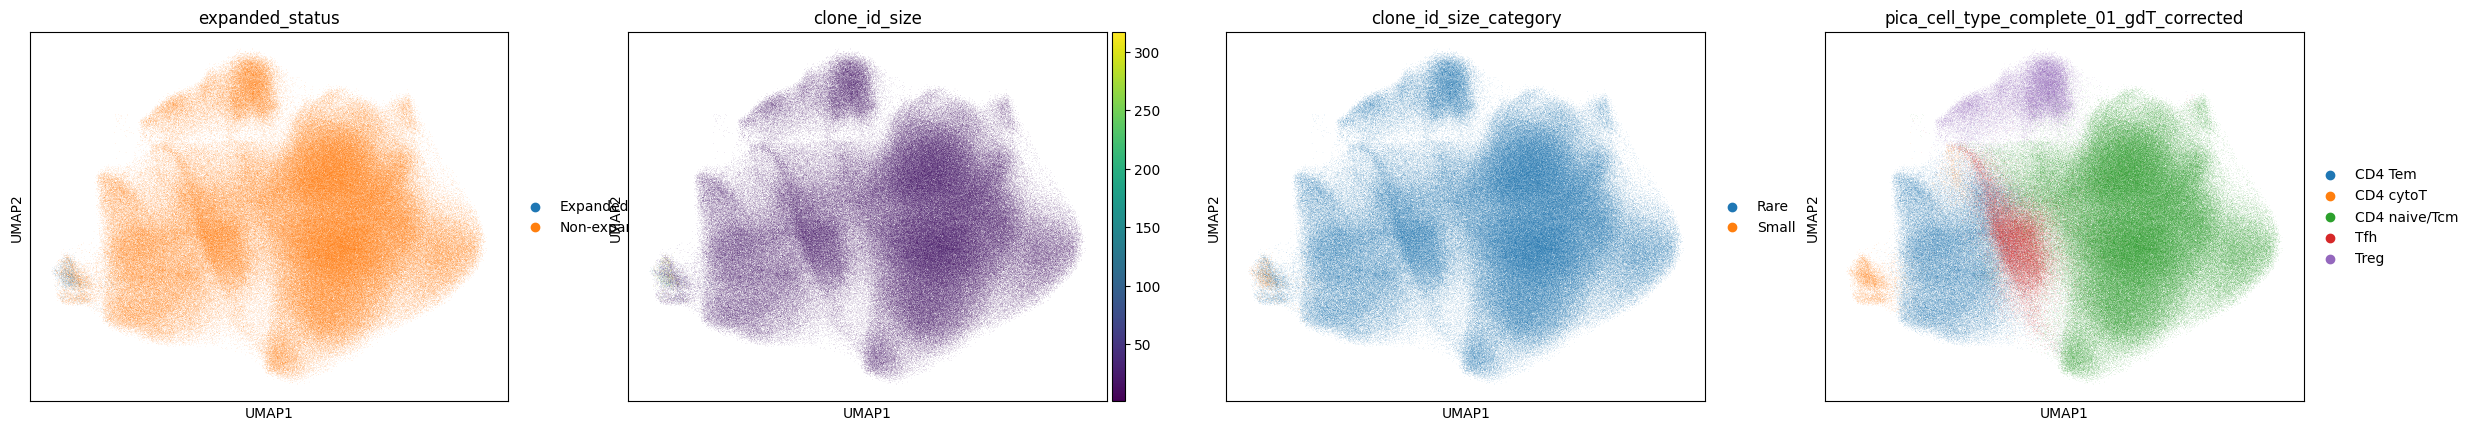

In [18]:
sc.pl.umap(
    adata_tcr,
    color=[
        "expanded_status",
        "clone_id_size",
        clone_cat_col,
        celltype_col,
    ],
    na_in_legend=False,
)

## visualization

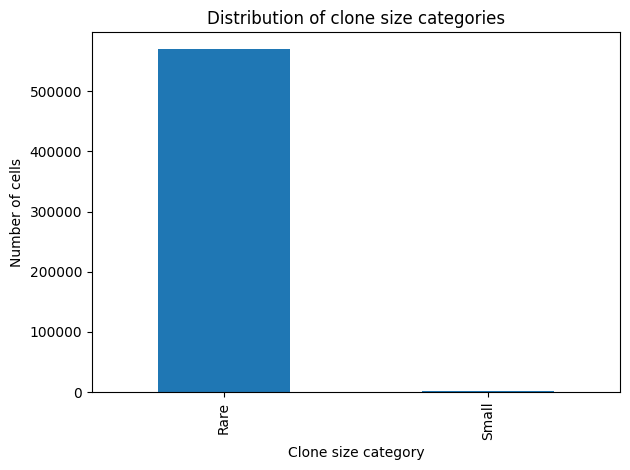

In [19]:
# Clone size distribution
clone_counts = (
    adata_tcr.obs[clone_cat_col]
    .value_counts(dropna=False)
)

clone_counts.plot(kind="bar")
plt.ylabel("Number of cells")
plt.xlabel("Clone size category")
plt.title("Distribution of clone size categories")
plt.tight_layout()
plt.show()

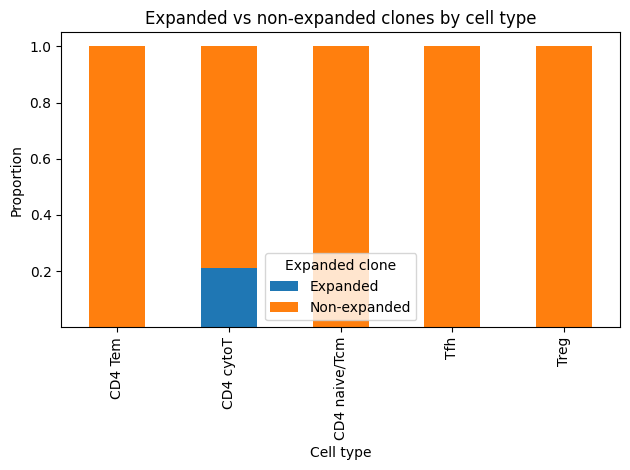

In [20]:
# Expanded clones by cell type
expanded_by_celltype = pd.crosstab(
    adata_tcr.obs[celltype_col],
    adata_tcr.obs["expanded_status"],
    normalize="index"
)

expanded_by_celltype.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Cell type")
plt.title("Expanded vs non-expanded clones by cell type")
plt.legend(title="Expanded clone")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


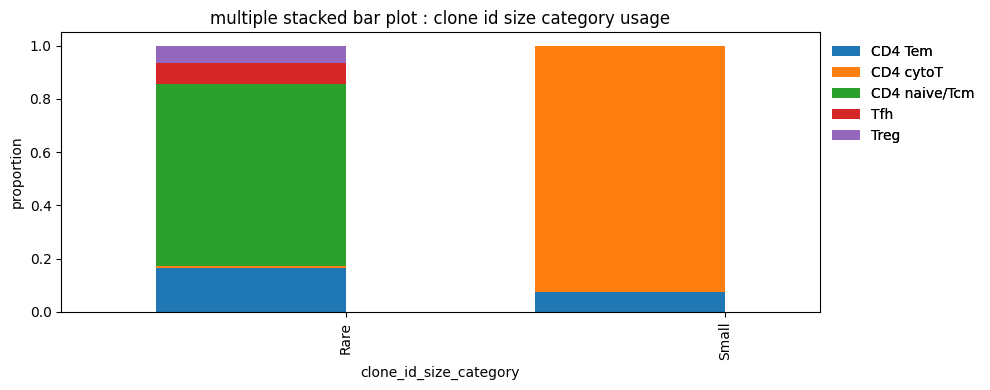

In [33]:
ddl.pl.stackedbarplot(
    adata_tcr,
    group_by=celltype_col,
    color=clone_cat_col,
    normalize=True,
    figsize=(10, 4),
)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

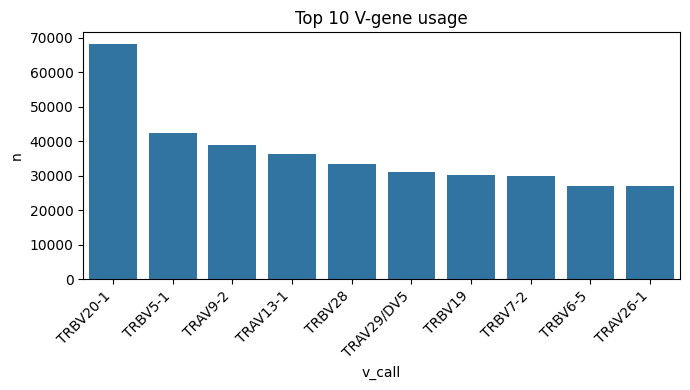

In [22]:
vdj_df = vdj_cd4.data.select(["cell_id", "v_call"]).collect().to_pandas()
vdj_df["cell_id"] = vdj_df["cell_id"].astype(str).str.replace("-1$", "", regex=True)

v_usage = (
    vdj_df.dropna(subset=["v_call"])
    .groupby("v_call")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="n")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=v_usage, x="v_call", y="n")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 V-gene usage")
plt.tight_layout()
plt.show()

## Donor level diversity estimation
- Shannon diversity
- Simpson diversity
- Inverse diversity
- Clonality
- Richness

In [23]:
# create donor level summary
adata_tcr.obs["expanded_flag"] = (
    adata_tcr.obs["clone_id_size_category"]
    .map({"Rare": 0, "Small": 1})
    .astype(float)
)

def shannon_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return entropy(p)

def simpson_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return np.sum(p ** 2)

donor_summary = (
    adata_tcr.obs.dropna(subset=["pica_id"])
    .groupby("pica_id")
    .agg(
        n_tcr_cells=("clone_id", "size"),
        n_clonotypes=("clone_id", pd.Series.nunique),
        Age_years=("Age_years", "first"),
        Age_group=("Age_group", "first"),
        Sex=("Sex", "first"),
    )
)

# add Shannon / Simpson / Clonality / expanded proportion only on non-null clone_id
clone_nonnull = adata_tcr.obs.dropna(subset=["pica_id", "clone_id"]).copy()

shannon_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(shannon_from_clone_ids)
simpson_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(simpson_from_clone_ids)

donor_summary["Shannon"] = shannon_by_donor
donor_summary["Simpson"] = simpson_by_donor
donor_summary["Clonality"] = 1 - donor_summary["Simpson"]

prop_expanded = (
    adata_tcr.obs
    .groupby("pica_id")["expanded_flag"]
    .mean()
)

donor_summary["prop_expanded"] = prop_expanded


donor_summary = donor_summary.reset_index()
display(donor_summary.head())

/scratch/temp/24288055/ipykernel_594608/1134017701.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_594608/1134017701.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_594608/1134017701.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_594608/1134017701.py:42: FutureWarning: The default of observed=False is deprecated a

,pica_id,n_tcr_cells,n_clonotypes,Age_years,Age_group,Sex,Shannon,Simpson,Clonality,prop_expanded
0,PICA0001,2317,2297,2.09,0–3,Male,7.729842,0.000455,0.999545,0.008200
1,PICA0002,971,967,15.09,15–18,Male,6.872616,0.001038,0.998962,0.000000
2,PICA0003,1144,1142,0.83,0–3,Male,7.039863,0.000877,0.999123,0.000000
3,PICA0008,7855,7635,9.70,7–10,Female,8.925543,0.000137,0.999863,0.000000
4,PICA0009,4451,4338,4.76,4–6,Female,8.357799,0.000249,0.999751,0.003595


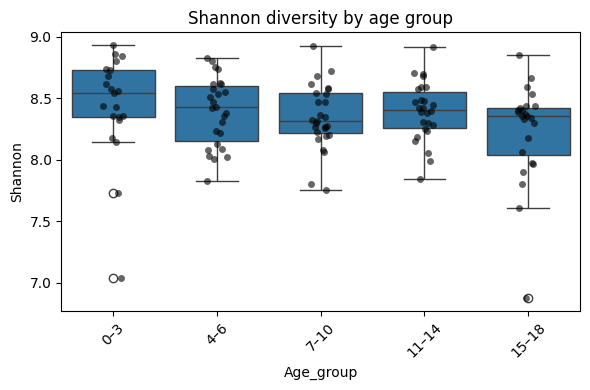

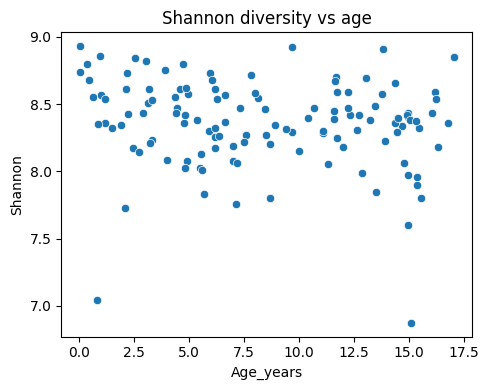

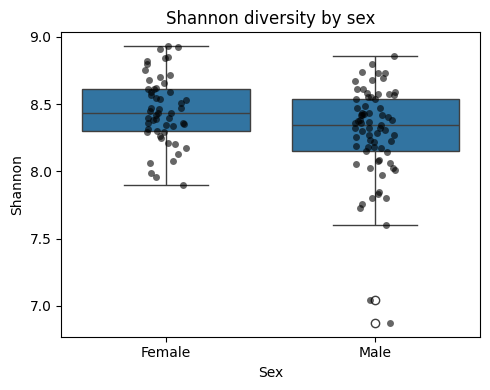

In [24]:
# shannon diversity
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Shannon")
sns.stripplot(data=donor_summary, x="Age_group", y="Shannon", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Shannon diversity by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Shannon")
plt.title("Shannon diversity vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Shannon")
sns.stripplot(data=donor_summary, x="Sex", y="Shannon", color="black", alpha=0.6)
plt.title("Shannon diversity by sex")
plt.tight_layout()
plt.show()

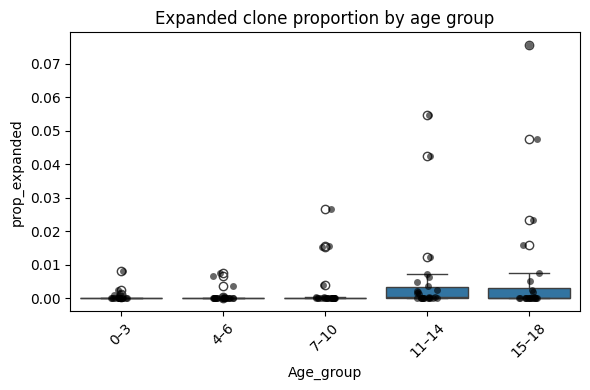

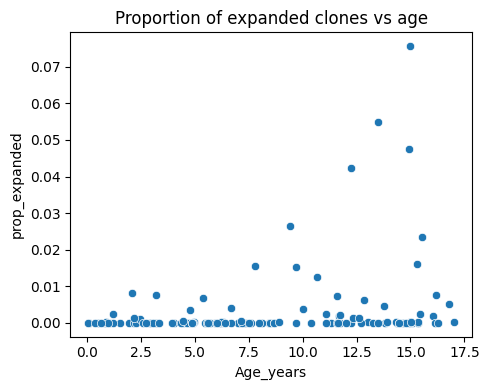

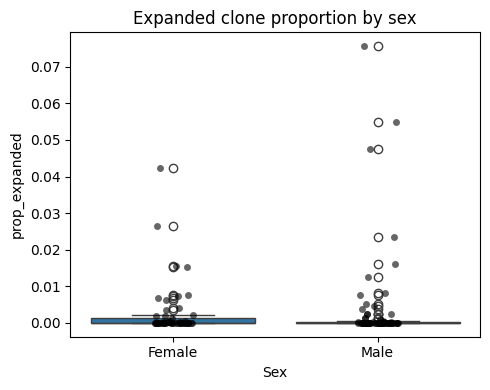

In [25]:
# expanded clone proportion
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Age_group", y="prop_expanded", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Expanded clone proportion by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="prop_expanded")
plt.title("Proportion of expanded clones vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Sex", y="prop_expanded", color="black", alpha=0.6)
plt.title("Expanded clone proportion by sex")
plt.tight_layout()
plt.show()


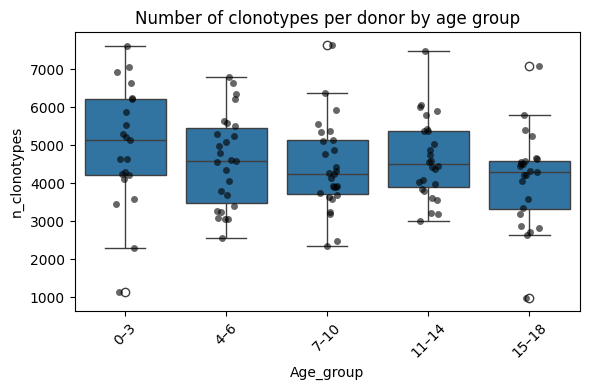

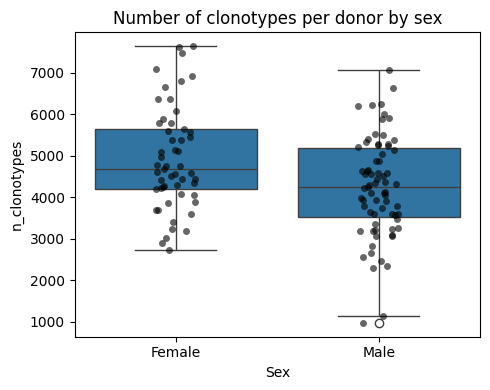

In [26]:
# clonotype richness
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Age_group", y="n_clonotypes", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Number of clonotypes per donor by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Sex", y="n_clonotypes", color="black", alpha=0.6)
plt.title("Number of clonotypes per donor by sex")
plt.tight_layout()
plt.show()

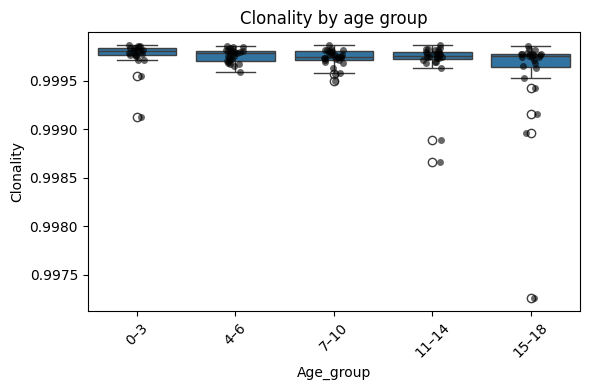

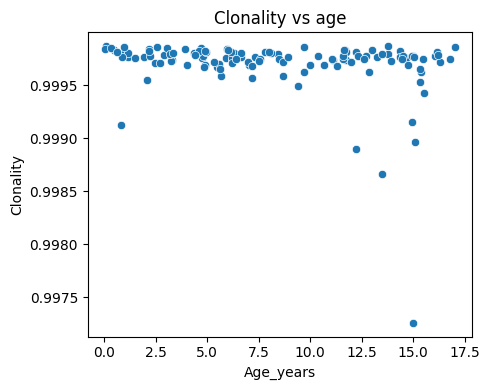

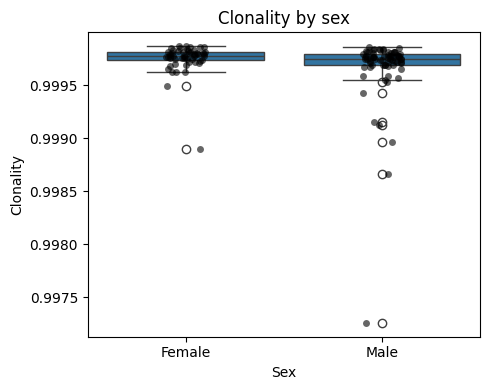

In [27]:
# clonality
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Clonality")
sns.stripplot(data=donor_summary, x="Age_group", y="Clonality", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Clonality by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Clonality")
plt.title("Clonality vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Clonality")
sns.stripplot(data=donor_summary, x="Sex", y="Clonality", color="black", alpha=0.6)
plt.title("Clonality by sex")
plt.tight_layout()
plt.show()

/scratch/temp/24288055/ipykernel_594608/716115582.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_594608/716115582.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


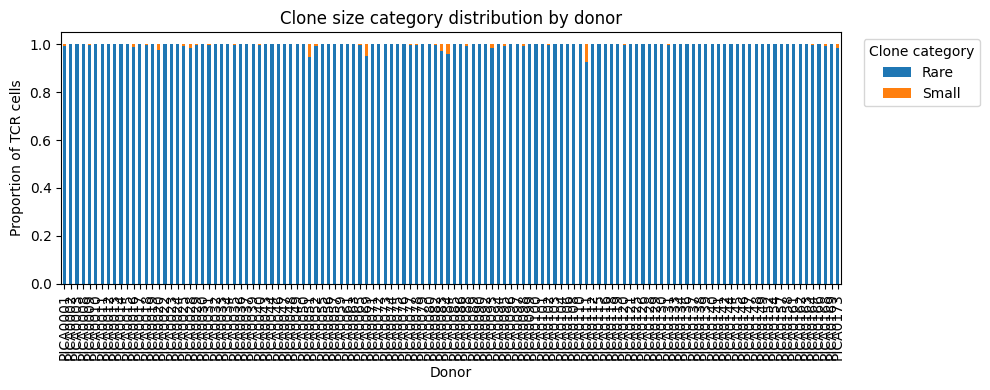

In [28]:
# clone size distribution
clone_dist = (
    adata_tcr.obs.dropna(subset=["pica_id", clone_cat_col])
    .groupby(["pica_id", clone_cat_col])
    .size()
    .rename("n_cells")
    .reset_index()
)

donor_totals = clone_dist.groupby("pica_id")["n_cells"].sum().rename("total_cells").reset_index()
clone_dist = clone_dist.merge(donor_totals, on="pica_id", how="left")
clone_dist["proportion"] = clone_dist["n_cells"] / clone_dist["total_cells"]

pivot_df = (
    clone_dist
    .pivot(index="pica_id", columns=clone_cat_col, values="proportion")
    .fillna(0)
)

clone_cols = [c for c in ["Rare", "Small"] if c in pivot_df.columns]
pivot_df = pivot_df[clone_cols]

pivot_df.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.ylabel("Proportion of TCR cells")
plt.xlabel("Donor")
plt.title("Clone size category distribution by donor")
plt.xticks(rotation=90)
plt.legend(title="Clone category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/scratch/temp/24288055/ipykernel_594608/1914076282.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


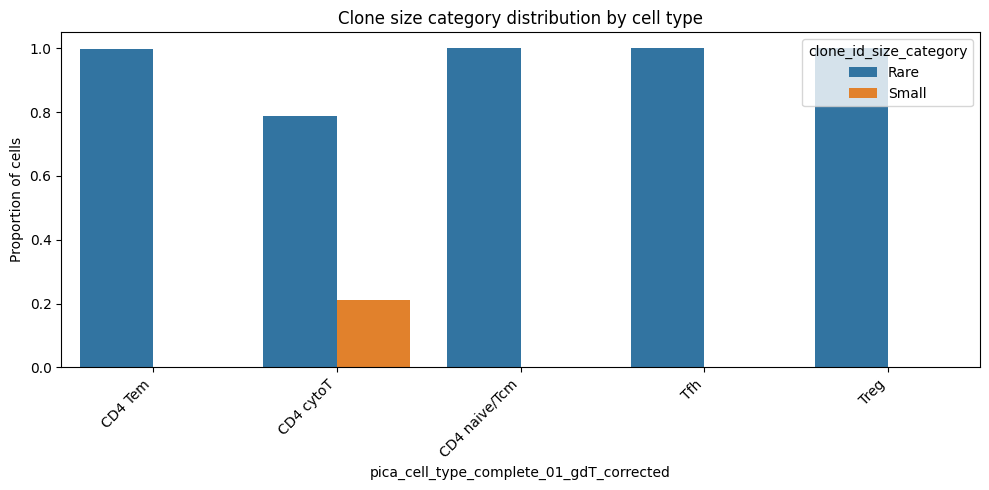

In [29]:
# cell type
clone_cat_prop = (
    adata_tcr.obs.groupby(celltype_col)[clone_cat_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=clone_cat_prop,
    x=celltype_col,
    y="proportion",
    hue=clone_cat_col,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of cells")
plt.xlabel(celltype_col)
plt.title("Clone size category distribution by cell type")
plt.tight_layout()
plt.show()

,Treg,CD4 cytoT,CD4 Tem,CD4 naive/Tcm,Tfh
Treg,1.000000,0.000040,0.000118,0.000020,0.000010
CD4 cytoT,0.000040,1.000000,0.001684,0.000016,0.000302
CD4 Tem,0.000118,0.001684,1.000000,0.000190,0.000653
CD4 naive/Tcm,0.000020,0.000016,0.000190,1.000000,0.000099
Tfh,0.000010,0.000302,0.000653,0.000099,1.000000


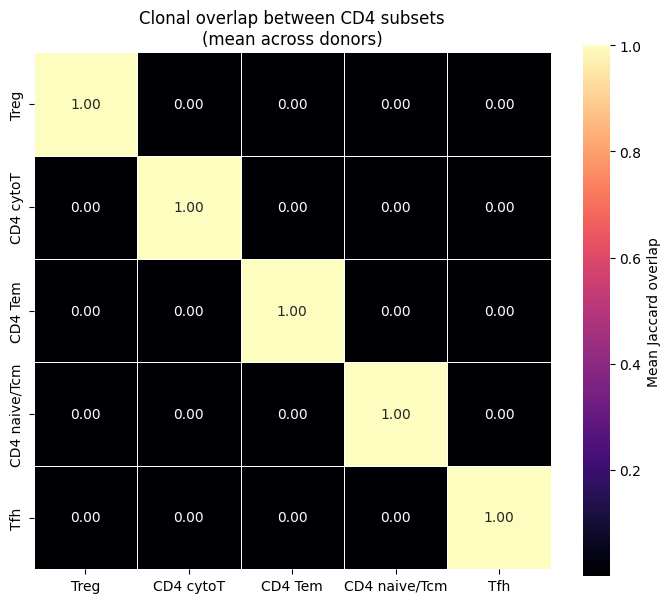

In [30]:
df_overlap = adata_tcr.obs[[celltype_col, "clone_id", "pica_id"]].copy()
df_overlap = df_overlap.dropna(subset=[celltype_col, "clone_id", "pica_id"])

preferred_order = ["Treg", "CD4 cytoT", "CD4 Tem", "CD4 naive/Tcm", "Tfh"]
celltypes = [ct for ct in preferred_order if ct in df_overlap[celltype_col].unique()]
remaining = sorted([ct for ct in df_overlap[celltype_col].unique() if ct not in celltypes])
celltypes = celltypes + remaining

donors = sorted(df_overlap["pica_id"].unique())

donor_mats = []
pairwise_records = []

for donor in donors:
    df_d = df_overlap[df_overlap["pica_id"] == donor].copy()

    clone_sets = {
        ct: set(df_d.loc[df_d[celltype_col] == ct, "clone_id"])
        for ct in celltypes
    }

    mat = pd.DataFrame(index=celltypes, columns=celltypes, dtype=float)

    for ct1 in celltypes:
        for ct2 in celltypes:
            s1 = clone_sets[ct1]
            s2 = clone_sets[ct2]
            inter = s1 & s2
            union = s1 | s2
            jaccard = len(inter) / len(union) if len(union) > 0 else np.nan
            mat.loc[ct1, ct2] = jaccard

            pairwise_records.append({
                "pica_id": donor,
                "celltype_1": ct1,
                "celltype_2": ct2,
                "n_shared_clones": len(inter),
                "n_union_clones": len(union),
                "jaccard_overlap": jaccard,
            })

    donor_mats.append(mat)

overlap_mean = pd.concat(donor_mats).groupby(level=0).mean()
overlap_mean = overlap_mean.loc[celltypes, celltypes]
overlap_long = pd.DataFrame(pairwise_records)

display(overlap_mean)

plt.figure(figsize=(7, 6))
sns.heatmap(
    overlap_mean,
    cmap="magma",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title("Clonal overlap between CD4 subsets\n(mean across donors)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
df_overlap = adata_tcr.obs[[celltype_col, "clone_id", "pica_id"]].copy()
df_overlap = df_overlap.dropna(subset=[celltype_col, "clone_id", "pica_id"])

preferred_order = ["Treg", "CD4 cytoT", "CD4 Tem", "CD4 naive/Tcm", "Tfh"]
celltypes = [ct for ct in preferred_order if ct in df_overlap[celltype_col].unique()]
remaining = sorted([ct for ct in df_overlap[celltype_col].unique() if ct not in celltypes])
celltypes = celltypes + remaining

donors = sorted(df_overlap["pica_id"].unique())

donor_mats = []
pairwise_records = []

In [ ]:
for donor in donors:
    df_d = df_overlap[df_overlap["pica_id"] == donor].copy()

    clone_sets = {
        ct: set(df_d.loc[df_d[celltype_col] == ct, "clone_id"])
        for ct in celltypes
    }

    mat = pd.DataFrame(index=celltypes, columns=celltypes, dtype=float)

    for ct1 in celltypes:
        for ct2 in celltypes:
            s1 = clone_sets[ct1]
            s2 = clone_sets[ct2]
            inter = s1 & s2
            union = s1 | s2
            jaccard = len(inter) / len(union) if len(union) > 0 else np.nan
            mat.loc[ct1, ct2] = jaccard

            pairwise_records.append({
                "pica_id": donor,
                "celltype_1": ct1,
                "celltype_2": ct2,
                "n_shared_clones": len(inter),
                "n_union_clones": len(union),
                "jaccard_overlap": jaccard,
            })

    donor_mats.append(mat)

overlap_mean = pd.concat(donor_mats).groupby(level=0).mean()
overlap_mean = overlap_mean.loc[celltypes, celltypes]
overlap_long = pd.DataFrame(pairwise_records)

display(overlap_mean)

plt.figure(figsize=(7, 6))
sns.heatmap(
    overlap_mean,
    cmap="magma",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title("Clonal overlap between CD4 subsets\n(mean across donors)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
ddl.tl.clone_overlap(adata_tcr, group_by="pica_id", weighted_overlap=True)
ddl.pl.clone_overlap(adata_tcr, group_by="pica_id", weighted_overlap=True)